In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNetCV
from sklearn.pipeline import make_pipeline
import seaborn as sns
import warnings
import math as m
sns.set_style('white')

# load
train_data_tr = pd.read_csv(r"data/case1Data.csv")
test_data_tr = pd.read_csv(r"data/case1Data_Xnew.csv")

X_tr = train_data_tr.loc[:].to_numpy()[:, 1:]
C_tr = train_data_tr.loc[:].to_numpy(dtype=int)[:, 96:]
X_te = test_data_tr.loc[:].to_numpy()

nan_id_tr = np.array(np.where(np.isnan(X_tr)))
nan_id_te = np.array(np.where(np.isnan(X_te)))
feature_means_tr = np.nanmean(X_tr, axis=0)
feature_stds_tr = np.nanstd(X_tr, axis=0)
feature_means_te = np.nanmean(X_te, axis=0)
feature_stds_te = np.nanstd(X_te, axis=0)

for nan_element in nan_id_tr.T:
    row_id, col_id = nan_element
    X_tr[row_id, col_id] = np.random.normal(loc=feature_means_tr[col_id], scale=feature_stds_tr[col_id])

for nan_element in nan_id_te.T:
    row_id, col_id = nan_element
    X_te[row_id, col_id] = np.random.normal(loc=feature_means_te[col_id], scale=feature_stds_te[col_id])

/home/borkeren/Desktop/CDA-HandIn/.venv/lib/python3.12/site-packages/pandas/core/internals/managers.py:1923: RuntimeWarning: invalid value encountered in cast
  result[rl.indexer] = arr


In [7]:
np.where(C_tr == -9223372036854775808)

(array([ 8,  8,  8,  8,  8, 10, 10, 10, 10, 10, 14, 14, 14, 14, 14, 16, 16,
        16, 16, 16, 21, 21, 21, 21, 21, 24, 24, 24, 24, 24, 28, 28, 28, 28,
        28, 30, 30, 30, 30, 30, 34, 34, 34, 34, 34, 40, 40, 40, 40, 40, 57,
        57, 57, 57, 57, 58, 58, 58, 58, 58, 59, 59, 59, 59, 59, 62, 62, 62,
        62, 62, 64, 64, 64, 64, 64, 66, 66, 66, 66, 66, 72, 72, 72, 72, 72,
        84, 84, 84, 84, 84, 85, 85, 85, 85, 85, 88, 88, 88, 88, 88, 91, 91,
        91, 91, 91, 99, 99, 99, 99, 99]),
 array([0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1,
        2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3,
        4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0,
        1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2,
        3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4, 0, 1, 2, 3, 4]))

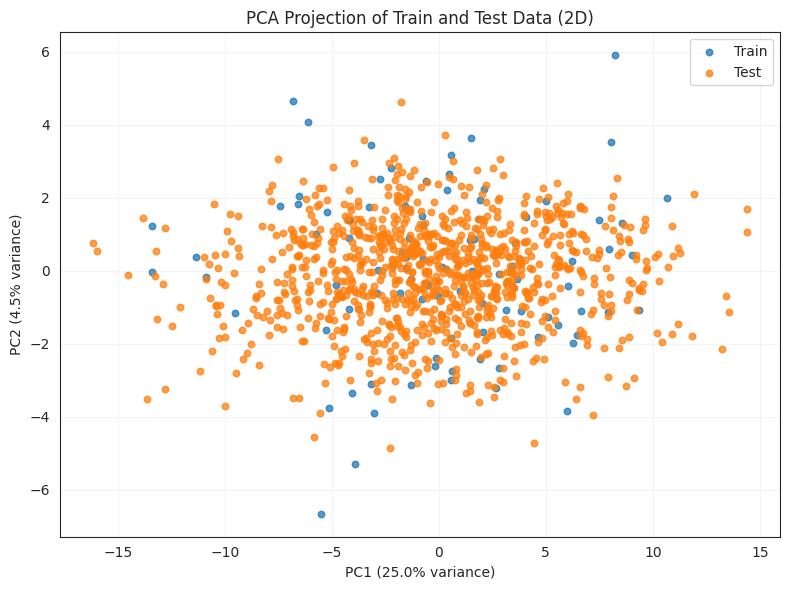

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

if X_tr.shape[1] < 2:
    raise ValueError("PCA 2D plot requires at least 2 features.")

# Fit scaling and PCA on train data only, then apply to test data.
scaler = StandardScaler()
X_tr_scaled = scaler.fit_transform(X_tr)
X_te_scaled = scaler.transform(X_te)

pca = PCA(n_components=2, random_state=42)
X_tr_pca = pca.fit_transform(X_tr_scaled)
X_te_pca = pca.transform(X_te_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tr_pca[:, 0], X_tr_pca[:, 1], s=22, alpha=0.75, label="Train")
plt.scatter(X_te_pca[:, 0], X_te_pca[:, 1], s=22, alpha=0.75, label="Test")
plt.title("PCA Projection of Train and Test Data (2D)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}% variance)")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()